# Measure nearest neighbor instrinsic dimension (NNID) of jets with Omnifold measurement

This notebook implements of measurement of the NNID of a sample of jets isolated from the ATLAS Omnifold measurement. This involves the following:

1. Cluster jets and isolate a randomly skimmed selection of jets within a pT bin (default 330 to 370 GeV) using every event sample needed to build the measurement.
2. Calculate the EMD between every jet in this selection. For computational reasons, we limit to 50k jets per event sample in the analysis.
3. Sort the columns of the EMD matrix into increasing order so nearest neighbors can be quickly computed
4. Use a negative log-likelihood minimization to extract the maximum likelihood estimate for the intrinsic dimension. This is done repeatedly for different values of the unphysical index "i" as specified in https://arxiv.org/pdf/2511.20760.

These fours steps will be done first for the pseudo-data measurement, and second for the data measurement.
Given the analysis is somewhat complicated and compute intensive, this notebook will take a long time to run even with resources that can run the calculations in parallel.

**Note**: Given the very large size of the sherpa sample the events are split into two pieces, each with an uproot file for the events and a HDF5 file for the weights.

## Preliminaries: load all data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import numpy as np
import pandas as pd
import fastjet as fj

import id_utils as utils
import visualize as vis

In [3]:
# ROOT file paths
staging_dir = "/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data"
tree_name = "OmniTree"

truth_mc_path = f"{staging_dir}/truth_mc_events.root"
truth_pseudodata_path = f"{staging_dir}/truth_pseudodata_events.root"
truth_hv_path = f"{staging_dir}/truth_mc_hv_events.root"
truth_madgraph_path = f"{staging_dir}/truth_madgraph/truth_madgraph_events.root"
truth_sherpa_paths = [
    f"{staging_dir}/truth_sherpa/truth_sherpa_events_part1.root",
    f"{staging_dir}/truth_sherpa/truth_sherpa_events_part2.root",
]

In [52]:
# Load event weights for pseudodata measurement
pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_weights.h5")
pseudodata_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/pseudodata_hv_weights.h5")
truth_pseudodata_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_pseudodata_weights.h5")

# Load event weights for data measurement
data_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_weights.h5")
data_hv_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/data_hv_weights.h5")
truth_madgraph_weights = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_madgraph/truth_madgraph_weights.h5")
truth_sherpa_weights1 = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_sherpa/truth_sherpa_weights_part1.h5")
truth_sherpa_weights2 = pd.read_hdf("/pscratch/sd/k/kgreif/zjets_plot_staging/final_public_data/truth_sherpa/truth_sherpa_weights_part2.h5")

## Calculate EMDs

WARNING: The below will require about 80 GB of disk space for the storage of EMD matrices.
Reduce the `max_jets` parameter to reduce disk footprint.

In [ ]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 330.0
ptmax = 370.0
etamax = 1.2
max_jets = 50000

# Set location for EMD storage, set to None to not save
emd_dir = "./emd_storage"
if not os.path.exists(emd_dir) and emd_dir is not None:
    os.makedirs(emd_dir)

In [ ]:
# Calculate EMDs for madgraph
utils.calculate_emds_from_file(
    truth_mc_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_emds_330to370.npz",
    save_jet_info=True,
)

In [ ]:
# Calculate EMDs for hidden variable events
utils.calculate_emds_from_file(
    truth_hv_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_mc_hv_emds_330to370.npz",
)

In [ ]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    truth_pseudodata_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_pseudodata_emds_330to370.npz",
)

In [ ]:
# Calculate EMDs for truth madgraph
utils.calculate_emds_from_file(
    truth_madgraph_path,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_madgraph_emds_330to370.npz",
)

In [ ]:
# Calculate EMDs for sherpa
utils.calculate_emds_from_file(
    truth_sherpa_paths,
    tree_name,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    n_jobs=-1,
    max_jets=max_jets,
    save_path="./emd_storage/truth_sherpa_emds_330to370.npz",
)

## Measurement with Pseudodata

All EMDs should have been calculated and written to disk.
The next step to produce the pseudodata measurement is to process all event weights into a dictionary.
This requires using the event indices stored in the .npz file to pull the correct event weights for each of the `max_jets` jets in the EMD matrices.
Each vector of event weights in the dictionary will be used to repeat the calculation of the NNID.

In [15]:
# Create dictionary containined all of the weight vectors needed for the pseudodata measurement
nominal_weights = pseudodata_weights["weights_nominal"].to_numpy()
n_init_weights = [name for name in pseudodata_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [name for name in pseudodata_weights.keys() if "weights_bootstrap_mc_" in name]
pd_weights = {
    "prior": pseudodata_weights["weights_prior"].to_numpy(),  # Also include weights for plotting the "prior" used in the measurement
    "nominal": nominal_weights,
    **{f"ensemble_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": pseudodata_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    **{f"bootstrap_mc_test_{i}": utils.poisson_bootstrap_weights(nominal_weights) for i in range(25)},
    "trackEffMain": pseudodata_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": pseudodata_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": pseudodata_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": pseudodata_weights["weights_trackPtScale"].to_numpy(),
    # "muCalID": pseudodata_weights["weights_muCalID"].to_numpy(),
    # "muCalMS": pseudodata_weights["weights_muCalMS"].to_numpy(),
    # "muCalResBias": pseudodata_weights["weights_muCalResBias"].to_numpy(),
    # "muCalScale": pseudodata_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": pseudodata_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": pseudodata_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": pseudodata_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": pseudodata_weights["weights_muEffTrig"].to_numpy(),
    "pileup": pseudodata_weights["weights_pileup"].to_numpy(),
    "lumi": pseudodata_weights["weights_lumi"].to_numpy(),
    "dd": pseudodata_weights["weights_dd"].to_numpy(),
    "target_dd": pseudodata_weights["target_dd"].to_numpy(),
    "hvhad": pseudodata_weights["weights_hvhad"].to_numpy(),
}
truth_pd_weights = {
    "truthpd": truth_pseudodata_weights["weights_nominal"].to_numpy(),
}
pd_hv_weights = {
    "hv": pseudodata_hv_weights["weights_hv"].to_numpy(),
}

In [6]:
# Load all EMDs needed for the pseudodata measurement
# Note the .npz file also contains a vector of event indices which can be used to assign the correct weights to each EMD
truth_mc_emds = "./emd_storage/truth_mc_emds_330to370.npz"
truth_pseudodata_emds = "./emd_storage/truth_pseudodata_emds_330to370.npz"
truth_mc_hv_emds = "./emd_storage/truth_mc_hv_emds_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_pseudodata_emds_zip = np.load(truth_pseudodata_emds)
truth_mc_hv_emds_zip = np.load(truth_mc_hv_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_pseudodata_emds = truth_pseudodata_emds_zip["emds"]
truth_pseudodata_evt_idx = truth_pseudodata_emds_zip["event_indices"]
truth_mc_hv_emds = truth_mc_hv_emds_zip["emds"]
truth_mc_hv_evt_idx = truth_mc_hv_emds_zip["event_indices"]

In [16]:
# Slice appropriate weights from the weights dictionary
sliced_pd_weights = {key: value[truth_mc_evt_idx] for key, value in pd_weights.items()}
sliced_truth_pd_weights = {key: value[truth_pseudodata_evt_idx] for key, value in truth_pd_weights.items()}
sliced_pd_hv_weights = {key: value[truth_mc_hv_evt_idx] for key, value in pd_hv_weights.items()}

To facilitate the NNID calculation, we sort each column of the (symmetric) EMD matrix into increasing order.
This makes it easy to find the ith (unweighted) nearest neighbor of a jet j by looking up the (i,j) entry.\
However we really want to find the **weighted** nearest neighbor as described below.
To do this, we also need to keep an array of the indices of the nearest neighbors for each jet.

In [8]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
sorted_truth_mc_emds, sorted_truth_mc_evt_idx = utils.sort_emd_matrix(truth_mc_emds)
sorted_truth_pseudodata_emds, sorted_truth_pseudodata_evt_idx = utils.sort_emd_matrix(truth_pseudodata_emds)
sorted_truth_mc_hv_emds, sorted_truth_mc_hv_evt_idx = utils.sort_emd_matrix(truth_mc_hv_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


Given $N$ events $\{x_k\}$ with associated weights $\{w_k\}$, we generalize the NNID estimator to the weighted setting.

### Weighted Neighbor Ranking

Rather than finding the $i$-th nearest neighbor by event count, we find the neighbor at **weighted rank** $i$. Concretely, for each event $x_k$:

1. Sort all other events by distance from $x_k$: $d_{k,1} \leq d_{k,2} \leq \cdots$
2. Accumulate weights in order of increasing distance
3. Define $r_{k,i}$ as the distance at which the cumulative weight first reaches $i$

This replaces the hard count $i$ with a weighted count, so that a nearby event with weight $w=5$ counts as much as 5 unit-weight events at the same distance.

### Weighted MLE

The log-likelihood becomes a weighted sum over events:

$$\mathcal{L}_w = -\bar{N} \log d + (1 + id) \sum_{k=1}^N w_k \log \mu_{k,ij} - (j-i-1) \sum_{k=1}^N w_k \log\!\left(1 - \mu_{k,ij}^{-d}\right)$$

where $\bar{N} = \sum_k w_k$ is the sum of weights and $\mu_{k,ij} = r_{k,j}/r_{k,i}$ uses the weighted neighbor distances above.

In [17]:
import id_utils as utils
thresholds = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
pd_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_emds,
    sorted_truth_mc_evt_idx,
    sliced_pd_weights,
    thresholds,
    n_jobs=20,
)
truth_pd_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_pseudodata_emds,
    sorted_truth_pseudodata_evt_idx,
    sliced_truth_pd_weights,
    thresholds,
    n_jobs=1,
)
pd_hv_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_hv_emds,
    sorted_truth_mc_hv_evt_idx,
    sliced_pd_hv_weights,
    thresholds,
    n_jobs=1,
)

Processing 175 weight sets for 86 thresholds...
Processing 175 weight sets using 20 workers...


Processing weight sets:   0%|          | 0/175 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets:   1%|          | 1/175 [01:02<3:01:01, 62.42s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-

Processing 1 weight sets for 86 thresholds...


Processing weight sets: 100%|██████████| 1/1 [00:25<00:00, 25.28s/set]


Processing 1 weight sets for 86 thresholds...


Processing weight sets: 100%|██████████| 1/1 [00:24<00:00, 24.52s/set]


In [18]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "pd_results_330to370.npz"), **pd_results)
np.savez(os.path.join(save_dir, "truth_pd_results_330to370.npz"), **truth_pd_results)
np.savez(os.path.join(save_dir, "pd_hv_results_330to370.npz"), **pd_hv_results)

### Plotting

In [19]:
# Load results from .npz files
save_dir = "./nnid_storage"
thresholds = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
pd_results_zip = np.load(os.path.join(save_dir, "pd_results_330to370.npz"))
pd_results = {key: pd_results_zip[key] for key in pd_results_zip.files}
truth_pd_results_zip = np.load(os.path.join(save_dir, "truth_pd_results_330to370.npz"))
truth_pd_results = {key: truth_pd_results_zip[key] for key in truth_pd_results_zip.files}
pd_hv_results_zip = np.load(os.path.join(save_dir, "pd_hv_results_330to370.npz"))
pd_hv_results = {key: pd_hv_results_zip[key] for key in pd_hv_results_zip.files}

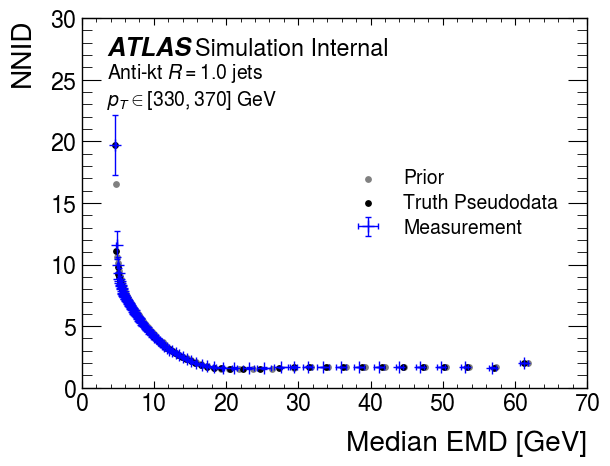

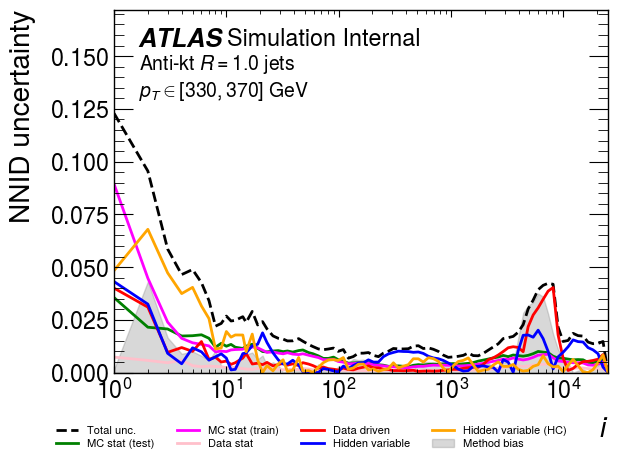

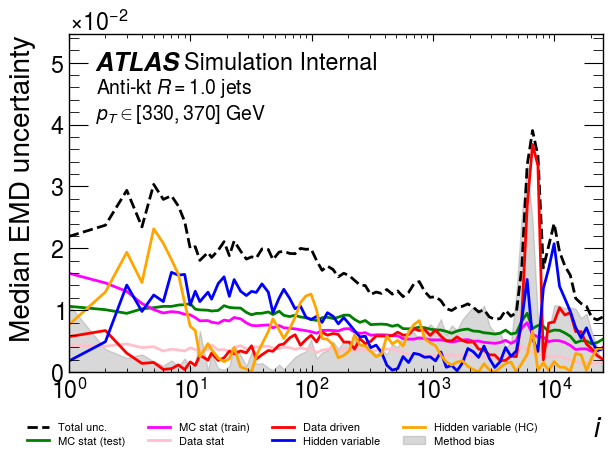

In [51]:
# Plot comparison to truth pseudodata
import visualize as vis
pd_plot, uc_nnid, uc_avgr = vis.plot_nnid_pseudodata(
    mc_results=pd_results,
    pd_results=truth_pd_results,
    hv_results=pd_hv_results,
    low_limit=0,
    high_limit=100,
    xlim=(0, 70),
    ylim=(0, 30),
    rlab="Anti-kt $R=1.0$ jets\n$p_T \in [330, 370]$ GeV",
    thresholds=thresholds,
    plot_uncertainty_budget=True,
    show_connector_lines=False,
)
pd_plot.savefig("./plot_storage/pd_nnid_emd.pdf", dpi=300)
pd_plot.show()
uc_nnid.savefig("./plot_storage/pd_budget_nnid.pdf", dpi=300)
uc_nnid.show()
uc_avgr.savefig("./plot_storage/pd_budget_median_emd.pdf", dpi=300)
uc_avgr.show()

## Measurement with data

### Calculation

In [86]:
# Create dictionary describing all of the histograms needed for the data measurement
nominal_weights = data_weights["weights_nominal"]
n_init_weights = [name for name in data_weights.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in data_weights.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_train_weights = [
    name for name in data_weights.keys() if "weights_bootstrap_mc_" in name
]
data_weights = {
    "nominal": data_weights["weights_nominal"].to_numpy(),
    **{f"ensemble_{i}": data_weights[name].to_numpy() for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": data_weights[name].to_numpy() for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": data_weights[name].to_numpy() for i, name in enumerate(mcbootstrap_train_weights)},
    **{f"bootstrap_mc_test_{i}": utils.poisson_bootstrap_weights(nominal_weights) for i in range(25)},
    "trackEffMain": data_weights["weights_trackEffMain"].to_numpy(),
    "trackEffJet": data_weights["weights_trackEffJet"].to_numpy(),
    "trackFake": data_weights["weights_trackFake"].to_numpy(),
    "trackPtScale": data_weights["weights_trackPtScale"].to_numpy(),
    # "muCalID": data_weights["weights_muCalID"].to_numpy(),
    # "muCalMS": data_weights["weights_muCalMS"].to_numpy(),
    # "muCalResBias": data_weights["weights_muCalResBias"].to_numpy(),
    # "muCalScale": data_weights["weights_muCalScale"].to_numpy(),
    "muEffReco": data_weights["weights_muEffReco"].to_numpy(),
    "muEffIso": data_weights["weights_muEffIso"].to_numpy(),
    "muEffTrack": data_weights["weights_muEffTrack"].to_numpy(),
    "muEffTrig": data_weights["weights_muEffTrig"].to_numpy(),
    "pileup": data_weights["weights_pileup"].to_numpy(),
    "lumi": data_weights["weights_lumi"].to_numpy(),
    "dd": data_weights["weights_dd"].to_numpy(),
    "target_dd": data_weights["target_dd"].to_numpy(),
    "hvhad": data_weights["weights_hvhad"].to_numpy(),
}
data_hv_weights = {
    "hv": data_hv_weights["weights_hv"].to_numpy(),
}
truth_madgraph_weights_dict = {
    "madgraph": truth_madgraph_weights["weights_nominal"],
    "weights_theoryQCD": truth_madgraph_weights["weights_theoryQCD"],
    "weights_theoryPDF": truth_madgraph_weights["weights_theoryPDF"],
    "weights_theoryAlphaS": truth_madgraph_weights["weights_theoryAlphaS"],
    "weights_theoryPSsoft": truth_madgraph_weights["weights_theoryPSsoft"],
    "weights_theoryPSjet": truth_madgraph_weights["weights_theoryPSjet"],
    "weights_theoryPSscale": truth_madgraph_weights["weights_theoryPSscale"],
    "weights_theoryMPI": truth_madgraph_weights["weights_theoryMPI"],
}
truth_sherpa_weights_dict = {
    "sherpa": np.concatenate([truth_sherpa_weights1["weights_nominal"], truth_sherpa_weights2["weights_nominal"]]),
    "weights_theoryQCD": np.concatenate([truth_sherpa_weights1["weights_theoryQCD"], truth_sherpa_weights2["weights_theoryQCD"]]),
    "weights_theoryPDF": np.concatenate([truth_sherpa_weights1["weights_theoryPDF"], truth_sherpa_weights2["weights_theoryPDF"]]),
    "weights_theoryAlphaS": np.concatenate([truth_sherpa_weights1["weights_theoryAlphaS"], truth_sherpa_weights2["weights_theoryAlphaS"]]),
}

In [87]:
# Load all EMDs needed for the data measurement
truth_mc_emds = "./emd_storage/truth_mc_emds_330to370.npz"
truth_mc_hv_emds = "./emd_storage/truth_mc_hv_emds_330to370.npz"
truth_madgraph_emds = "./emd_storage/truth_madgraph_emds_330to370.npz"
truth_sherpa_emds = "./emd_storage/truth_sherpa_emds_330to370.npz"

truth_mc_emds_zip = np.load(truth_mc_emds)
truth_mc_hv_emds_zip = np.load(truth_mc_hv_emds)
truth_madgraph_emds_zip = np.load(truth_madgraph_emds)
truth_sherpa_emds_zip = np.load(truth_sherpa_emds)

truth_mc_emds = truth_mc_emds_zip["emds"]
truth_mc_evt_idx = truth_mc_emds_zip["event_indices"]
truth_mc_hv_emds = truth_mc_hv_emds_zip["emds"]
truth_mc_hv_evt_idx = truth_mc_hv_emds_zip["event_indices"]
truth_madgraph_emds = truth_madgraph_emds_zip["emds"]
truth_madgraph_evt_idx = truth_madgraph_emds_zip["event_indices"]
truth_sherpa_emds = truth_sherpa_emds_zip["emds"]
truth_sherpa_evt_idx = truth_sherpa_emds_zip["event_indices"]

In [88]:
# Slice appropriate weights from the weights dictionary
sliced_data_weights = {
    key: value[truth_mc_evt_idx] for key, value in data_weights.items()
}
sliced_data_hv_weights = {
    key: value[truth_mc_hv_evt_idx] for key, value in data_hv_weights.items()
}
sliced_truth_madgraph_weights = {
    key: value[truth_madgraph_evt_idx] for key, value in truth_madgraph_weights_dict.items()
}
sliced_truth_sherpa_weights = {
    key: value[truth_sherpa_evt_idx] for key, value in truth_sherpa_weights_dict.items()
}

In [89]:
# Sort EMDs for faster NNID calculation
# Note the sorting and take along operations are done in parallel with numba
sorted_truth_mc_emds, sorted_truth_mc_evt_idx = utils.sort_emd_matrix(truth_mc_emds)
sorted_truth_mc_hv_emds, sorted_truth_mc_hv_evt_idx = utils.sort_emd_matrix(truth_mc_hv_emds)
sorted_truth_madgraph_emds, sorted_truth_madgraph_evt_idx = utils.sort_emd_matrix(truth_madgraph_emds)
sorted_truth_sherpa_emds, sorted_truth_sherpa_evt_idx = utils.sort_emd_matrix(truth_sherpa_emds)

Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)
Sorting EMD matrix (parallel with numba)...
Sorted EMD matrix with shape (50000, 50000)


In [90]:
# Now calculate the NNID estimator for all values if i and all weight sets
# This involves a numerical minimization of the likelihood at each point and for each weight set
thresholds = np.unique(np.logspace(np.log10(1), np.log10(25e3), 100, dtype=int))
data_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_emds,
    sorted_truth_mc_evt_idx,
    sliced_data_weights,
    thresholds,
    n_jobs=20,
)
data_hv_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_mc_hv_emds,
    sorted_truth_mc_hv_evt_idx,
    sliced_data_hv_weights,
    thresholds,
    n_jobs=1,
)
truth_madgraph_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_madgraph_emds,
    sorted_truth_madgraph_evt_idx,
    sliced_truth_madgraph_weights,
    thresholds,
    n_jobs=len(sliced_truth_madgraph_weights),
)
truth_sherpa_results = utils.calculate_nnids_from_sorted_emds(
    sorted_truth_sherpa_emds,
    sorted_truth_sherpa_evt_idx,
    sliced_truth_sherpa_weights,
    thresholds,
    n_jobs=len(sliced_truth_sherpa_weights),
)

Processing 174 weight sets for 86 thresholds...
Processing 174 weight sets using 20 workers...


Processing weight sets:   0%|          | 0/174 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value enc

Processing 1 weight sets for 86 thresholds...


Processing weight sets:   0%|          | 0/1 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets: 100%|██████████| 1/1 [00:24<00:00, 24.27s/set]


Processing 8 weight sets for 86 thresholds...
Processing 8 weight sets using 8 workers...


Processing weight sets:   0%|          | 0/8 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encou

Processing 4 weight sets for 86 thresholds...
Processing 4 weight sets using 4 workers...


Processing weight sets:   0%|          | 0/4 [00:00<?, ?set/s]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets:  25%|██▌       | 1/4 [00:30<01:30, 30.32s/set]/global/common/software/m3246/conda/eflow/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
Processing weight sets: 100%|██████████| 4/4 [00:32<00:00,  8.20s/se

In [91]:
# Store the results in .npz files
save_dir = "./nnid_storage"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
np.savez(os.path.join(save_dir, "data_results_330to370.npz"), **data_results)
np.savez(os.path.join(save_dir, "data_hv_results_330to370.npz"), **data_hv_results)
np.savez(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"), **truth_madgraph_results)
np.savez(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"), **truth_sherpa_results)

### Plotting

In [92]:
# Load results from .npz files
save_dir = "./nnid_storage"
data_results_zip = np.load(os.path.join(save_dir, "data_results_330to370.npz"))
data_results = {key: data_results_zip[key] for key in data_results_zip.files}
data_hv_results_zip = np.load(os.path.join(save_dir, "data_hv_results_330to370.npz"))
data_hv_results = {key: data_hv_results_zip[key] for key in data_hv_results_zip.files}
truth_madgraph_results_zip = np.load(os.path.join(save_dir, "truth_madgraph_results_330to370.npz"))
truth_madgraph_results = {key: truth_madgraph_results_zip[key] for key in truth_madgraph_results_zip.files}
truth_sherpa_results_zip = np.load(os.path.join(save_dir, "truth_sherpa_results_330to370.npz"))
truth_sherpa_results = {key: truth_sherpa_results_zip[key] for key in truth_sherpa_results_zip.files}

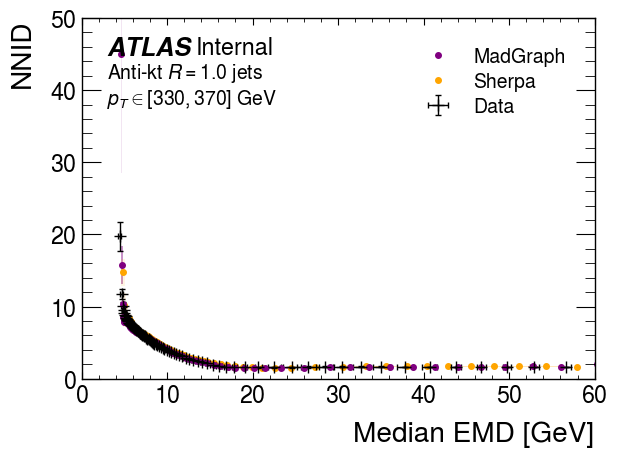

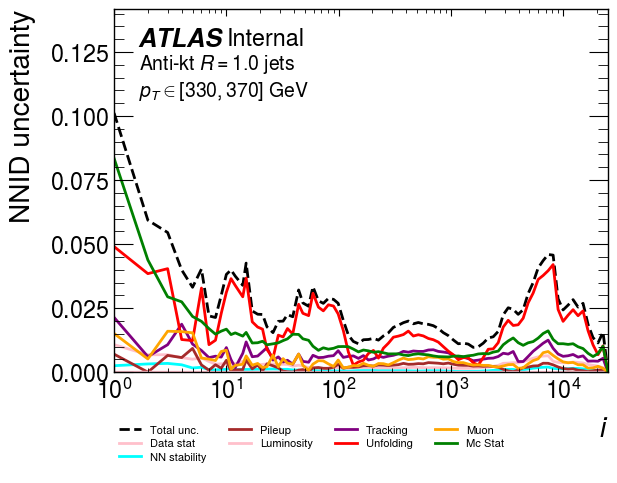

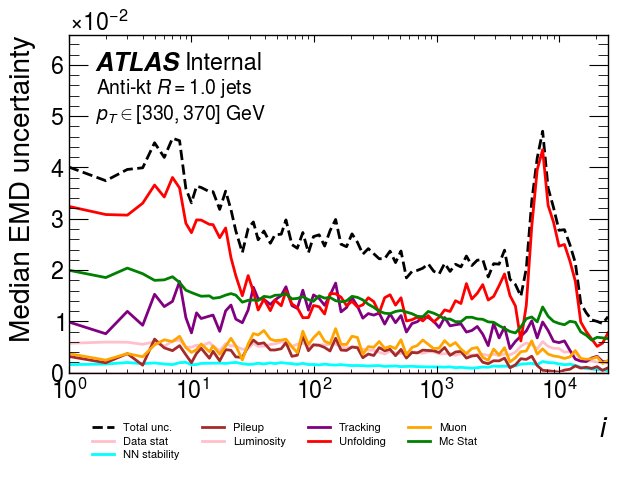

In [134]:
import visualize as vis
data_plot, uc_nnid, uc_avgr = vis.plot_nnid_data(
    mc_results=data_results,
    hv_results=data_hv_results,
    madgraph_results=truth_madgraph_results,
    sherpa_results=truth_sherpa_results,
    low_limit=0,
    high_limit=100,
    thresholds=thresholds,
    plot_uncertainty_budget=True,
    xlim=(0, 60),
    ylim=(0, 50),
    yscale="linear",
    rlab="Anti-kt $R=1.0$ jets\n$p_T \in [330, 370]$ GeV",
)
data_plot.savefig("plot_storage/data_nnid.pdf", dpi=300)
data_plot.show()
uc_nnid.savefig("plot_storage/data_budget_nnid.pdf", dpi=300)
uc_nnid.show()
uc_avgr.savefig("plot_storage/data_budget_median_emd.pdf", dpi=300)
uc_avgr.show()